# Projet : Filtrage de Kalman
_Auteur : ClapTrap – Objectif : Réaliser un filtre qui retrouve biais et angle d'un IMU en déplacement 1D(rot) pour lequel on dispose des mesures d'accélération et de gyroscopie_
_Date : 2026-04-03_
---


## 1. Configuration de Colab (optionnel)

Cette section gère la connexion à Google Drive ou d'autres éléments spécifiques à Colab.

In [52]:
# Monter Google Drive (optionnel si vous voulez accéder à vos fichiers)
from google.colab import drive
drive.mount('/content/gdrive')

# Définir un chemin de travail principal (optionnel)
BaseWorkingPath = "/content/gdrive/MyDrive/ColabProjects/ExampleProject"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 2. Installation et import des bibliothèques

Regrouper ici toutes les installations `pip` propres à Colab et tous les imports.

In [53]:
# Installation des dépendances spécifiques (si nécessaire)
# Exemple : !pip install numpy scipy matplotlib

!pip install filterpy  # <<<

import math
import numpy as np
import matplotlib.pyplot as plt

# Optionnel : configuration d'affichage
np.set_printoptions(precision=4, suppress=True)

from filterpy.kalman import KalmanFilter

## 3. Définition des paramètres globaux

Centraliser ici les constantes, chemins, et paramètres configurables.

In [54]:
# Paramètres globaux
InputDataPath = BaseWorkingPath + "/input"
OutputDataPath = BaseWorkingPath + "/output"

# DefaultSampleSize = 100  # nombre d'instants de mesure  # <<<
TotalTime = 100
DefaultSampleSize = 1000  # nombre d'instants de mesure  # <<<

RandomSeed = 123
np.random.seed(RandomSeed)

# Paramètres du modèle de mouvement  # <<<
# TimeStep = 1.0                      # intervalle de temps (secondes)  # <<<
TimeStep = int(TotalTime/DefaultSampleSize) # intervalle de temps (secondes)  # <<<
TrueInitialAlpha = 0.0           # position initiale vraie         # <<<
TrueInitialAlphadot = 0.0
TrueInitialBias = 10           # vitesse vraie (m/s)             # <<<
MeasurementAlphaNoiseStd = 5.0           # => R écart-type du bruit de mesure   # <<<
MeasurementAlphadotNoiseStd = 5.0           # => R écart-type du bruit de mesure   # <<<
ProcessAlphaNoiseStd = 1   # => Q bruit de processus (accélération)  # <<<
ProcessAlphadotNoiseStd = 1   # => Q bruit de processus (accélération)  # <<<
ProcessBiasNoiseStd = 1   # => Q bruit de processus (accélération)  # <<<

## 4. Définition des fonctions principales

Regrouper ici les fonctions réutilisables pour le traitement.

In [55]:
def GenerateTrueValuesAndMeasurements(sampleSize: int):
    """
    Generate values with piecewise constant acceleration
    and noisy position measurements.
    """
    timeArray = np.arange(sampleSize, dtype=float) * TimeStep
    print(f"timeArray : {timeArray}, len : {len(timeArray)}")
    trueAlphaArray = np.zeros(sampleSize, dtype=float)
    trueAlphadotArray = np.zeros(sampleSize, dtype=float)

    currentAlpha = TrueInitialAlpha
    currentAlphadot = TrueInitialAlphadot

    for indexTime in range(sampleSize):
        currentTime = timeArray[indexTime]

        # Acceleration profile (piecewise)
        if currentTime < 20.0:
            currentAlphadotdot = 0.0
        elif currentTime < 40.0:
            currentAlphadotdot = 0.5
        elif currentTime < 60.0:
            currentAcceleration = -0.3
        else:
            currentAlphadotdot = 0.0

        currentAlphadot = currentAlphadot + currentAlphadotdot * TimeStep
        currentAlpha = currentAlpha + currentAlphadot * TimeStep

        trueAlphaArray[indexTime] = currentAlpha
        trueAlphadotArray[indexTime] = currentAlphadot

    print(f"trueAlphaArray : {trueAlphaArray}, len : {len(trueAlphaArray)}")
    print(f"trueAlphaDotArray : {trueAlphadotArray}, len : {len(trueAlphadotArray)}")

    measurementNoiseArray = np.random.normal(
        loc=0.0,
        scale=MeasurementAlphaNoiseStd,
        size=sampleSize
    )
    measuredAlphaArray = trueAlphaArray + measurementNoiseArray

    measurementNoiseArray = np.random.normal(
        loc=0.0,
        scale=MeasurementAlphadotNoiseStd,
        size=sampleSize
    )
    measuredAlphadotArray = trueAlphadotArray + measurementNoiseArray

    return timeArray, trueAlphaArray, trueAlphadotArray, measuredAlphaArray, measuredAlphadotArray

In [56]:
def CreateKalmanFilter():
    """

    """
    kalmanFilter = KalmanFilter(dim_x=3, dim_z=2)

    kalmanFilter.x = np.array([
        [TrueInitialAlpha],
        [TrueInitialAlphadot],
        [TrueInitialBias]
      ])

    kalmanFilter.F = np.array([
        [1.0, TimeStep, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0]
        ])

    kalmanFilter.H = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 1.0]
        ])

    kalmanFilter.P = np.array([
        [500.0, 0.0, 0.0],
        [0.0, 500.0, 0.0],
        [0.0, 0.0, 500.0]
        ])

    kalmanFilter.R = np.diag([
        MeasurementAlphaNoiseStd ** 2,
        MeasurementAlphadotNoiseStd ** 2
        ])

    # q = ProcessNoiseStdAcceleration ** 2
    # dt = TimeStep
    # kalmanFilter.Q = np.array([
    #     [0.25 * dt**4 * q, 0.5 * dt**3 * q],
    #     [0.5 * dt**3 * q,  dt**2 * q]
    # ])

    kalmanFilter.Q = np.diag([
        ProcessAlphaNoiseStd ** 2,
        ProcessAlphadotNoiseStd ** 2,
        ProcessBiasNoiseStd ** 2
        ])

    return kalmanFilter

In [57]:
def ApplyKalmanFilterOnMeasurements(kalmanFilter: KalmanFilter,
                                    measuredAlphaArray: np.ndarray,
                                    measuredAlphadotArray: np.ndarray,
                                    ):
    """
    Apply the Kalman filter step-by-step on noisy measurements
    and return estimated position and velocity arrays.
    """
    estimatedAlphaList = []
    estimatedAlphadotList = []
    estimatedBiasList = []

    for measuredAlpha, measuredAlphadot in zip(measuredAlphaArray, measuredAlphadotArray):
        kalmanFilter.predict()
        kalmanFilter.update(np.array([[measuredAlpha, measuredAlphadot]]))

        estimatedAlphaList.append(float(kalmanFilter.x[0, 0]))
        estimatedAlphadotList.append(float(kalmanFilter.x[1, 0]))
        estimatedBiasList.append(float(kalmanFilter.x[2, 0]))

    estimatedAlphaArray = np.array(estimatedAlphaList)
    estimatedAlphadotArray = np.array(estimatedAlphadotList)
    estimatedBiasArray = np.array(estimatedBiasList)

    return estimatedAlphaArray, estimatedAlphadotArray, estimatedBiasArray

In [58]:
# @title
def CompareVelocityEstimationsForProcessNoise(
    processNoiseStdAccelerationList,
    measuredPositionArray: np.ndarray
):
    """
    Run the Kalman filter for several values of ProcessNoiseStdAcceleration
    and return a dictionary of estimated velocity arrays.
    """
    estimationDict = {}

    for processNoiseStd in processNoiseStdAccelerationList:
        global ProcessNoiseStdAcceleration
        ProcessNoiseStdAcceleration = processNoiseStd

        kalmanFilter = CreateKalmanFilterFor1DPosition()

        (_, estimatedVelocityArray) = ApplyKalmanFilterOnMeasurements(
            kalmanFilter,
            measuredPositionArray
        )

        estimationDict[processNoiseStd] = estimatedVelocityArray

    return estimationDict

## 5. Exécution principale

Utiliser les fonctions définies pour produire les résultats.

In [59]:
# Génération du comportement vrai et des mesures bruitées
(TimeArray,
 TrueAlphaArray,
 TrueAlphadotArray,
 MeasuredAlphaArray,
 MeasuredAlphadotArray) = GenerateTrueValuesAndMeasurements(DefaultSampleSize)

timeArray : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [60]:
# Création et configuration du filtre de Kalman
KalmanFilter = CreateKalmanFilter()

In [61]:
# Application du filtre sur toutes les mesures
(EstimatedAlphaArray,
 EstimatedAlphadotArray,
 EstimatedBiasArray) = ApplyKalmanFilterOnMeasurements(
    KalmanFilter,
    MeasuredAlphaArray,
    MeasuredAlphadotArray
)

print("FirstTrueAlpha     =", TrueAlphaArray[0])
print("FirstMeasuredAlpha =", MeasuredAlphaArray[0])
print("FirstEstimatedAlpha =", EstimatedAlphaArray[0])
print("FirstTrueAlphadot     =", TrueAlphadotArray[0])
print("FirstEstimatedAlphadot =", EstimatedAlphadotArray[0])

FirstTrueAlpha     = 0.0
FirstMeasuredAlpha = -5.428153016502806
FirstEstimatedAlpha = -5.17016095298081
FirstTrueAlphadot     = 0.0
FirstEstimatedAlphadot = -6.704783642893356


## 6. Visualisation des résultats

Tracer les données ou les résultats principaux.

In [62]:
print(TimeArray)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

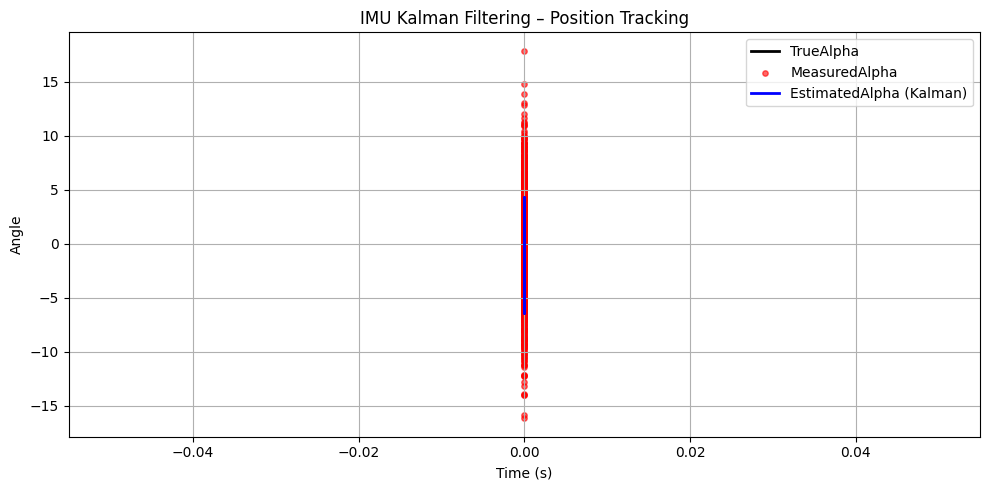

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(TimeArray,
         TrueAlphaArray,
         label="TrueAlpha",
         color="black",
         linewidth=2)

plt.scatter(TimeArray,
            MeasuredAlphaArray,
            label="MeasuredAlpha",
            color="red",
            s=15,
            alpha=0.6)

plt.plot(TimeArray,
         EstimatedAlphaArray,
         label="EstimatedAlpha (Kalman)",
         color="blue",
         linewidth=2)

plt.title("IMU Kalman Filtering – Position Tracking")
plt.xlabel("Time (s)")
plt.ylabel("Angle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

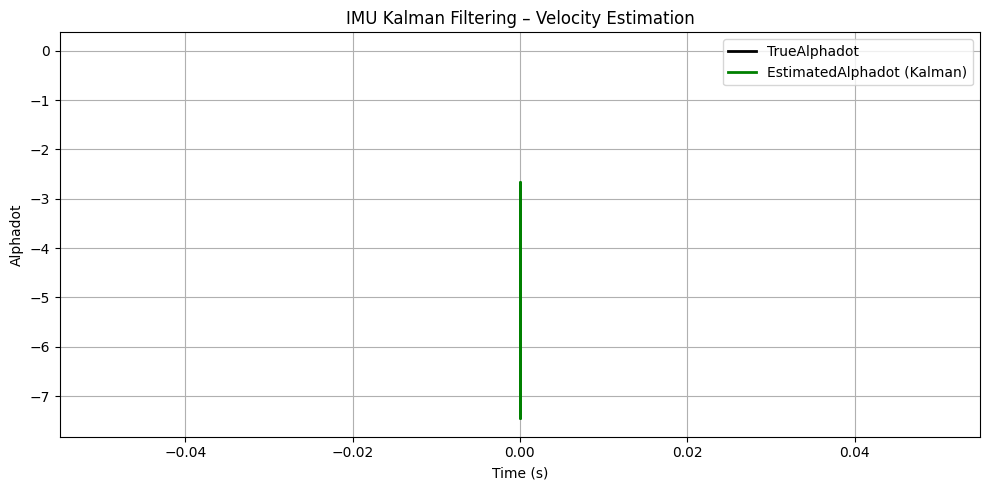

In [64]:
plt.figure(figsize=(10, 5))  # <<<

plt.plot(TimeArray,
         TrueAlphadotArray,
         label="TrueAlphadot",
         color="black",
         linewidth=2)  # <<<

plt.plot(TimeArray,
         EstimatedAlphadotArray,
         label="EstimatedAlphadot (Kalman)",
         color="green",
         linewidth=2)  # <<<

plt.title("IMU Kalman Filtering – Velocity Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Alphadot")  # <<<
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Conclusion et prochaines étapes

Voici les paramètres essentiels :

    x : état courant estimé du système, ici position et vitesse.

    F : matrice de transition d’état ; elle décrit comment l’état évolue d’un pas de temps au suivant selon le modèle choisi. Ici, avec une vitesse supposée constante, la nouvelle position vaut ancienne position + vitesse ×× pas de temps.

    H : matrice d’observation ; elle indique ce que l’on mesure effectivement. Ici, on ne mesure que la position, pas la vitesse.

    P : covariance initiale de l’erreur d’état ; elle représente l’incertitude initiale du filtre sur sa propre estimation. Une grande valeur signifie « je ne suis pas très sûr de mon état initial ».

    R : bruit de mesure ; il représente l’incertitude sur le capteur ou sur les observations. Dans votre code, R = MeasurementNoiseStd ** 2, donc c’est la variance du bruit de mesure.

    Q : bruit de processus ; il modélise les écarts entre le modèle théorique et la réalité. Ici, il représente en pratique de petites accélérations non modélisées alors que votre modèle suppose une vitesse constante.

In [65]:
ProcessNoiseStdAccelerationList = [0.05, 0.2, 0.8]

VelocityEstimationsDict = CompareVelocityEstimationsForProcessNoise(
    ProcessNoiseStdAccelerationList,
    MeasuredPositionArray
)

plt.figure(figsize=(10, 5))

plt.plot(TimeArray,
         TrueVelocityArray,
         label="TrueVelocity",
         color="black",
         linewidth=2)

colorList = ["blue", "green", "orange"]

for indexNoise, processNoiseStd in enumerate(ProcessNoiseStdAccelerationList):
    estimatedVelocityArray = VelocityEstimationsDict[processNoiseStd]

    plt.plot(TimeArray,
             estimatedVelocityArray,
             label=f"EstimatedVelocity Q={processNoiseStd}",
             color=colorList[indexNoise],
             linewidth=1.5)

plt.title("Velocity Estimation for Different Process Noise Std")
plt.xlabel("Time (s)")
plt.ylabel("Velocity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'MeasuredPositionArray' is not defined